<br>
<br>

# `#Simple 3D:`

### **Workflow:**

- 1. **Input: Point Cloud**
- 2. **Convertion: Point Cloud -> Voxel Grid(binary_cube)**
- 3. **Voxel Grid to Patches to embeddings(tokens)**
- 4. **Swin3D Blocks -> (local+shifted attention)**
- 5. **Hierarchical downsampling -> capture global shape features**
- 6. **Final head -> Based on tasks**
<br>
<br>

In [3]:
# pytorch-> timm model
# %pip install --upgrade git+https://github.com/rwightman/pytorch-image-models.git

In [6]:
import os 
import random 

import trimesh
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 
from mpl_toolkits.mplot3d import Axes3D

import torch 
import torch.nn as nn 
import torch.nn.functional as F 
from torch.utils.data import DataLoader,Dataset

from timm.layers import DropPath,trunc_normal_

c:\Users\CSITOCT\Desktop\swin3D\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:

# code reporducibility:
random.seed(42)
torch_seed = torch.random.manual_seed(42)


In [8]:

# device comptibility:
device = "cuda" if torch.cuda.is_available() else "cpu"
device = torch.device(device)
device

device(type='cuda')

<br>
<br>

# `#01: Input: Point Cloud`

<br>
<br>

In [11]:

path = r"C:\Users\CSITOCT\.cache\kagglehub\datasets\balraj98\modelnet40-princeton-3d-object-dataset\versions\1"
obj = os.listdir(f"{path}\{os.listdir(path)[1]}")[10]
obj_path = os.listdir(f"{path}\\{os.listdir(path)[1]}\\{obj}\\train")[0]
final_path = f"{path}\\{os.listdir(path)[1]}\\{obj}\\train\\{obj_path}"
final_path


<string>:2: SyntaxWarning: invalid escape sequence '\{'
<>:2: SyntaxWarning: invalid escape sequence '\{'
<string>:2: SyntaxWarning: invalid escape sequence '\{'
<>:2: SyntaxWarning: invalid escape sequence '\{'
C:\Users\CSITOCT\AppData\Local\Temp\2\ipykernel_15056\716235813.py:2: SyntaxWarning: invalid escape sequence '\{'
  obj = os.listdir(f"{path}\{os.listdir(path)[1]}")[10]
<string>:2: SyntaxWarning: invalid escape sequence '\{'


'C:\\Users\\CSITOCT\\.cache\\kagglehub\\datasets\\balraj98\\modelnet40-princeton-3d-object-dataset\\versions\\1\\ModelNet40\\cup\\train\\cup_0001.off'

In [12]:

# read files as point colud:
pointcloud = trimesh.load(final_path)
pointcloud = np.array(pointcloud.vertices)
pointcloud.shape


(3244, 3)

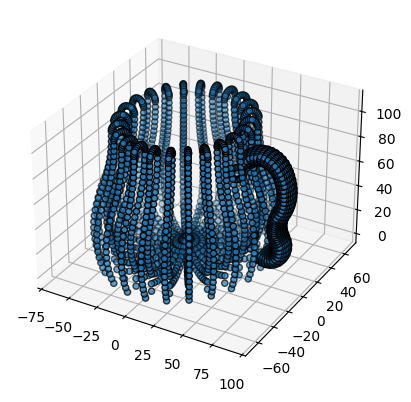

In [13]:

#visuliza the point colud:
ax = plt.figure()
fig = ax.add_subplot(111,projection='3d')
fig.scatter(pointcloud[:,0],pointcloud[:,1],pointcloud[:,2],edgecolors="black")
plt.show()

<br>
<br>

# `#02 Convertion: Point Cloud -> Voxel Grid(binary_cube)`

<br>
<br>

In [14]:

# 16^3 = need less memory but quality is not good enough 
# 32^3 = optimum
# 64^3 = high image details but need high memory power

def voxelize(points,grid_size=32):
    # normilize the points: (if value some value 0->1e-6)
    points = (points - points.min(0)) / (points.max(0) - points.min(0) + 1e-6)

    #scaling the value: (base on grid_size-1)->range(0 to 31)=32 values
    coords = (points*(grid_size-1)).astype(int)

    #In the airplane image there are empy spaces: 
    # 0 -> empty spaces
    # 1 -> object have value or voxel
    voxel_grid = np.zeros(shape=(grid_size,grid_size,grid_size),dtype=np.uint8)
    voxel_grid[coords[:,0],coords[:,1],coords[:,2]] = 1
    return voxel_grid

voxel = voxelize(points=pointcloud)
print(voxel.shape)
print(voxel.ndim)


(32, 32, 32)
3


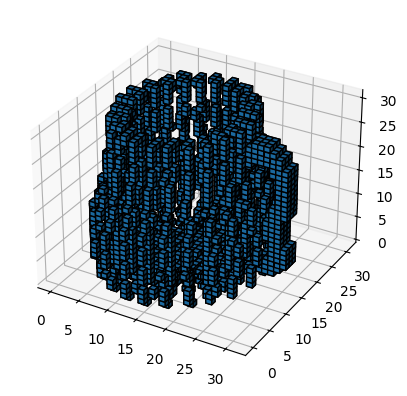

In [15]:

#visuliza the voxel colud:
ax = plt.figure()
fig = ax.add_subplot(111,projection='3d')
fig.voxels(voxel,edgecolors="black")
plt.show()


<br>

- ## Swin3D Block Diagram:

```md
Point Cloud: [3244, 3]
    ↓ (Voxelization)
Voxel Grid: [32, 32, 32] 
    ↓ (Add batch dimension)
Model Input: [B, 1, 32, 32, 32]
    ↓ (PatchEmbed3D)
Stage 1: [B, 512, 96]
    ├─ Swin3DBlock × 2
    └─ PatchMerging3D → [B, 64, 192]
    ↓
Stage 2: [B, 64, 192]  
    ├─ Swin3DBlock × 2
    └─ PatchMerging3D → [B, 8, 384]
    ↓
Stage 3: [B, 8, 384]
    ├─ Swin3DBlock × 6
    └─ PatchMerging3D → [B, 1, 768]
    ↓
Stage 4: [B, 1, 768]
    └─ Swin3DBlock × 2
    ↓
Classification Head → [B, 40]
```

- ## PatchEmbed3D:
```md
Input: [1, 1, 32, 32, 32]
    ↓ 3D Conv (kernel=4, stride=4, filters=96)
Output: [1, 96, 8, 8, 8] --> (32,32,32)--> (32-2*4-4)/2 + 1 = 8, see the formula from my note.
    ↓ Flatten spatial dimensions --> (8*8*8)=512
Output: [1, 96, 512]  
    ↓ Transpose dimensions
Final: [1, 512, 96]
```

<br>

# `#3: Voxel Grid to Patches to embeddings(tokens)`

<br>

In [ ]:



class PatchEmbedded(nn.Module):
    def __init__(self,in_channel,embed_dim,patch_size):
        super().__init__()
        self.patch_size = patch_size
        self.proj = nn.Conv3d(
            in_channels=in_channel,
            out_channels=embed_dim,
            kernel_size=patch_size,
            stride=patch_size
        )
    def forward(self,x):
        """ 
            Args:
                x[B,1,32,32,32]
        """
        x = self.proj(x) #[B,96,8,8,8]
        x = x.flatten(2) #[B,96,8*8*8]
        x = torch.transpose(x,dim0=1,dim1=2)
        return x 

<br>
<br>

# `#4: Window Attention 3D: W-MSA3D and SW-MSA3D`
<br>

## Positional Embedding Comparasion And Memory Efficiency Comparasion:

* **Vanilla Self-Attention**: It uses **fixed, non-learnable positional encodings** based on sinusoidal functions. This information is **added to the token embeddings** to give the model a sense of position.

* **Vision Transformer (ViT)**: It improves on this by using **learnable positional encodings**. These are also **added to the patch embeddings**, but unlike the fixed ones, they can be optimized during training.

* **Swin Transformer (2D)**: It introduces a more efficient approach with **learnable relative positional bias**. This is not added to the patch embeddings but directly **added to the attention scores** within each window. This allows the model to learn the spatial relationships between patches locally without a global memory cost.

* **Swin3D**: It takes the Swin concept a step further by using **Contextual Relative Signal Encoding (CRSE)**. This approach is similar to the 2D version but is applied to 3D voxels. The key difference is that it learns relationships not only from **relative XYZ coordinates** but also from other contextual features like **color (RGB)** and **surface normals**. This provides the model with a richer understanding of the 3D data's context.

<br>

### **Swin vs. Vanilla Attention Complexity:**

The Swin Transformer's key advantage over Vanilla Attention is its superior memory and computational efficiency. While Vanilla Attention computes a global attention matrix with a memory complexity of **$O(N^2 \times N_H)$**, Swin Transformer optimizes this by focusing on local windows. This approach drastically reduces the memory complexity to **$O(M^2 \times N_W \times N_H)$**, where $M$ is the window size and $N_W$ is the number of windows, making it highly effective for processing high-resolution images and 3D data. `research paper, section: 3.1`

<br>


In [17]:


class WindowsAttention3D(nn.Module):
    """
    dim: 
    quant size: (grid size in voxilization process->point-cloud to voxel-grid)
    windows_size: 
    num_heads: 
    qkv: 
    qk_scale:
    """
    def __init__(
            self,
            dim, # dimention of input feature:((x,y,z)) if have RBG then (r,g,b). total = 6
            quant, # cRSE: Quantization 
            window_size,
            num_heads,
            qkv_bias=True,
            qk_scale=None,
            atten_drop=0.0,
            proj_drop=0.0,
            cRSE="XYZ_RGB" # which feature will be taken by cRSE 
            ):
        super().__init__()
        self.dim = dim 
        self.window_size = window_size
        self.num_heads = num_heads
        self.head_dim = dim // num_heads
        self.qk_scale = qk_scale or self.head_dim**-0.5  # 1/root(head_dim)

        # CRPE: similar to relative positional bias in SWIN 
        """ 
        A 3D image is composed of multiple 2D images stacked along the height dimension, and we should
        process all the 2D image to extract both local and global fine-grained details.
        **That's Why XYZ and RGB window size=2x2**
        """
        self.cRSE = cRSE 
        self.color_windowsize = 2 
        self.normal_windowsize = 2 


        """ 
        **In vanila we just calculate attention, but in both swin2d
        and swin3d, we add  relative positional distance with attention score 
        and we calculate relative postion between query and key***

        query,key,value vector size for look up table:
        - xyz,rgb,norm -> 3 dim 
        - 2*quant_size*window_size 
            - we process a cross sectional image, finally we need: (quant_size) -> make voxel
            - window_size: for a single image we need, window_size value 
            - 2, we will calculate 2 value for each window voxel we calculate two value
        """
        if "XYZ" in cRSE:
            self.xyz_quant_size = quant
            quant_grid_length = window_size * self.xyz_quant_size
            table_shape_xyz = (3,2*quant_grid_length,num_heads,self.head_dim)

            self.query_xyz_table = nn.Parameter(torch.zeros(table_shape_xyz)) #3,2*grid_length,num_heads,head_dim
            self.key_xyz_table = nn.Parameter(torch.zeros(table_shape_xyz))
            self.value_xyz_table = nn.Parameter(torch.zeros(table_shape_xyz))
        
            trunc_normal_(self.query_xyz_table,std=0.02)
            trunc_normal_(self.key_xyz_table,std=0.02)
            trunc_normal_(self.value_xyz_table,std=0.02)

        """ 
        #In, swin3D official repo they use 
        fp16_mode for mixed_precision tranning.
        table_offset: for tranning the model into multiple gup efficiently.
        we are ignoring that
        """


        """ 
        query pixel's color 100, key pixel color 130 → difference: +30
        query pixel's color 150, key pixel color 120 → difference: -30
        We multipy the quant_size *2, cause here we are calculate both postive and 
        negative color pixel difference
        """
        if "RGB" in cRSE:
            self.color_quant_size = quant*2 
            quant_grid_length = self.color_windowsize * self.color_quant_size
            table_shape_rgb = (3,2*quant_grid_length,num_heads,self.head_dim)

            self.query_rgb_table = nn.Parameter(torch.zeros(table_shape_rgb))
            self.key_rgb_table = nn.Parameter(torch.zeros(table_shape_rgb))
            self.value_rgb_table = nn.Parameter(torch.zeros(table_shape_rgb))
        
            trunc_normal_(self.query_rgb_table,std=0.02)
            trunc_normal_(self.key_rgb_table,std=0.02)
            trunc_normal_(self.value_rgb_table,std=0.02)


        """ 
        similar like rgb:
            +ve difference or -ve difference
        """
        if "NORM" in cRSE:
            self.norm_quant_size = quant*2 
            quant_grid_length = self.normal_windowsize * self.norm_quant_size
            table_shape_norm = (3,2*quant_grid_length,num_heads,self.head_dim)

            self.query_norm_table = nn.Parameter(torch.zeros(table_shape_norm))
            self.key_norm_table = nn.Parameter(torch.zeros(table_shape_norm))
            self.value_norm_table = nn.Parameter(torch.zeros(table_shape_norm))
        
            trunc_normal_(self.query_norm_table,std=0.02)
            trunc_normal_(self.key_norm_table,std=0.02)
            trunc_normal_(self.value_norm_table,std=0.02)

        self.quant_size = quant
        self.qkv = nn.Linear(in_features=dim,out_features=3*dim,bias=qkv_bias)
        self.atten_drop = nn.Dropout(atten_drop,inplace=True)

        # After computing attention for merging heads
        self.proj = nn.Linear(in_features=dim,out_features=dim)
        self.proj_drop = nn.Dropout(proj_drop,inplace=True)

        # we need probability distribution: -1
        self.softmax = nn.Softmax(dim=-1)



    # ====================== Calculate Relative Positional Encoding ======================
    def get_relative_position_encoding(self,win_coords,feature_tye,win_q,win_k,win_v):
        """ 
            win_coords: [N,best_case=9]
        """
        Nw = win_coords.shape[0]
        if feature_tye=="XYZ":
            table_q = self.query_xyz_table ##3,2*grid_length,num_heads,head_dim
            table_k = self.key_xyz_table
            table_v = self.value_xyz_table
            quant_size = self.quant_size
            window_size = self.window_size
            coords = win_coords[:,0:3] #xyz
        elif feature_tye=="RGB":
            table_k = self.key_rgb_table
            table_q = self.query_rgb_table
            table_v = self.value_rgb_table
            quant_size = self.color_quant_size
            window_size = self.color_windowsize
            coords = win_coords[:,3:6]#rgb
        elif feature_tye=="NORM":
            table_q = self.query_norm_table
            table_k = self.key_norm_table
            table_v = self.value_norm_table
            quant_size = self.norm_quant_size
            window_size = self.normal_windowsize
            coords = win_coords[:,6:9]
        else:
            return None, None, None 
        
        #calculate relative difference:
        # [-15, -2, 0, 5, 12] 
        rel_coords = coords.unsqueeze(1) - coords.unsqueeze(0) # unsqueeze: add 1 dim [Nw,Nw,3]
        #quantize relative:
        quant_rel = torch.floor(rel_coords*quant_size)

        #shift to positive indices:(-ve,+ve, see in look up table in constructor) = 32
        quant_grid_length = window_size * quant_size

        # [-15+32, -2+32, 0+32, 5+32, 12+32]  = [17, 30, 32, 37, 44]
        quant_rel_shifted = quant_rel + quant_grid_length

        # Clamp to valid range: min_val=0,max_val=2*quant_grid_length-1
        # y_i = min(max(xi​,min_valuei​),max_value_i​), (0,2*32-1=63)
        quant_rel_shifted = quant_rel_shifted.clamp(0, 2 * quant_grid_length - 1)

        # get value from look up table:
        rpe_q = torch.zero(Nw,Nw,self.num_heads,self.head_dim,device=win_coords.device)
        rpe_k = torch.zeros_like(rpe_q)
        rpe_v = torch.zeros_like(rpe_k)
        for dim in range(3):
            # add relative encoding from look_Up table
            indices = quant_rel_shifted[:, :, dim]  # [Nw, Nw]
            rpe_q += table_q[dim][indices] # [Nw,Nw,num_heads,head_dim]
            rpe_k += table_k[dim][indices]
            rpe_v += table_v[dim][indices]
        return rpe_q, rpe_k, rpe_v


    # ====================== *******Forward Method******** ======================
    def forward(self,feats:torch.Tensor,n_coords:torch.Tensor):
        """
        Args:
            feats---------->Learned Feature by the model
            feats: [N,C] = Input voxel features:()

            n_corrds------->Actual data
            n_corrds: (XYZ,RGB,NORM): 9 dim in best case
                where: 
                N = total num of points:
                | Point ID | X   | Y   | Z   | R   | G   | B   | Nx  | Ny  | Nz  |
                | -------- | --- | --- | --- | --- | --- | --- | --- | --- | --- |  
                | 0        | 0.1 | 0.2 | 1.3 | 255 | 100 | 90  | 0.5 | 0.2 | 0.8 |
                | 1        | 0.4 | 0.1 | 1.1 | 200 | 150 | 80  | 0.6 | 0.1 | 0.7 |
                | 2        | 0.9 | 0.3 | 1.0 | 240 | 120 | 95  | 0.7 | 0.3 | 0.6 |
                  .
                  .
                  N 

        
        Returns:
            [N,c]: updated_feats after window attention 
        """
        
        """ 
        #for calculating attention score we need q,k,v
        # feature projection: (generation of: q,k,v)
        # q: What i am looking for 
        # k: what i have 
        # v: actual value 
        """
        N,C = feats.shape 
        qkv = self.qkv(feats) # [N, 3*C]
        qkv = qkv.reshape(N,3,self.num_heads,self.head_dim).permute(1,0,2,3) #(3,N,num_head,head_dim)
        q,k,v = qkv.unbind(0) #(1,N,num_head,head_dim)

        

        """ 
        # Now, divide the 3D space into grid/small-windows-> Benefit: 
           i)Parallel Processing  
           ii)Capture local context
        # Take only first, 3 dim: (x,y,z,r,g,b,norm)= (x,y,z)
        """
        xyz_coords = n_coords[:,0:3] # (x,y,z)
        # windows index: 
        # xyz_coords= [3.7, 1.2, 5.9],window_size=2
        # [3.7/2, 1.2/2, 5.9/2] = [1.85, 0.6, 2.95]
        # floor = [1, 0, 2] means, the voxel point occur in (1,0,2) position in window
        windows_idx = torch.floor(xyz_coords/self.window_size).long()
        # inverse track which a point belong which window
        # inverse = [0, 2, 1, 0, 2, 0]
        # 1st point in window no: 0, 2nd point in window no:2, 3rd point in window no: 1 
        unique_windows, inverse = torch.unique(windows_idx, dim=0, return_inverse=True)
        # find the number of unique windows
        num_windows = unique_windows.shape[0]



        """ 
        # calculate relative position in this for loop:
        # increase time complexity but reduce space complexity:(Beneficial)
        # we use absolute relative postional encoding: (In vanila transformer)
        """
        update_feats = torch.zeros_like(feats)
        for win_id in range(num_windows):
            # [0, 2, 1, 0, 2, 0], 6 point contains in 3(0,1,2) window
            # if win_id=0 then, mask [True,False,False,True,False,True]
            mask = (inverse==win_id)
            # fetch which point are in current indexies
            # mask.nonzero()->[[0],[3],[5]]->dim(3,1):(index where mask==True), 
            # squeeze: remove dim (3,1) = (3)
            win_indxes = mask.nonzero().squeeze(1) #[Nw]
            #shape of win_indexes here = 3
            Nw = win_indxes.shape[0] 
            # if we have no point in our current window return it
            if Nw==0:
                continue

            # now, the point belonging the current window, caluclate: q,k,v + coordinate(for calculating relative position)
            win_q = q[win_indxes] #
            win_k = k[win_indxes]
            win_v = v[win_indxes]
            win_coords = n_coords[win_indxes] #[xyz,rgb,norm]

            #<-----------initialize relative positional Encoding:------------------------>
            rpe_q_total = torch.zeros(Nw, Nw, self.num_heads, self.head_dim, device=feats.device)
            rpe_k_total = torch.zeros_like(rpe_q_total)
            rpe_v_total = torch.zeros_like(rpe_q_total)

            """
            - <:Calculate Relative positional Encoding:> for each feature
            Offset value: 
                 0      	XYZ coordinates (0:3)	3D position information
                 3	        RGB values (3:6)	    Color information
                 6      	Normal vectors (6:9)	Surface orientation
            """
            if "XYZ" in self.cRSE:
                rpe_q,rpe_k,rpe_v = self.get_relative_position_encoding(win_coords,"XYZ",win_q,win_k,win_v)
                if rpe_q is not None:
                    rpe_q_total +=rpe_q ## [Nw,Nw,num_heads,head_dim]
                    rpe_k_total +=rpe_k
                    rpe_v_total +=rpe_v
                
            if "RGB" in self.cRSE:
                rpe_q,rpe_k,rpe_v = self.get_relative_position_encoding(win_coords,"RGB",win_q,win_k,win_v)
                if rpe_q is not None:
                    rpe_q_total +=rpe_q
                    rpe_k_total +=rpe_k
                    rpe_v_total +=rpe_v
                
            if "NORM" in self.cRSE:
                rpe_q,rpe_k,rpe_v = self.get_relative_position_encoding(win_coords,"NORM",win_q,win_k,win_v)
                if rpe_q is not None:
                    rpe_q_total +=rpe_q
                    rpe_k_total +=rpe_k
                    rpe_v_total +=rpe_v
                
            
            # calculate attention_score with relative positional encoding:
            # Q * K^T
            # einsum(input->output,tensor1,tensor2,---)
            """ 
            win_q: [Nw, num_heads, head_dim] → indices: i,h,d

            win_k: [Nw, num_heads, head_dim] → indices: j,h,d

            Output: [Nw, Nw, num_heads] → indices: i,j,h

            what about d:
            output[i,j,h] = Σ_d (win_q[i,h,d] × win_k[j,h,d])
            """
            atten_score = torch.einsum("ihd,jhd->ijh",win_q,win_k)

            # add relative positonal bias (from researchpaper: 4.3.2)
            attn_scores += torch.einsum('ihd,ijhd->ijh', win_q, rpe_k_total)  # Q * RPE_k
            attn_scores += torch.einsum('ijhd,jhd->ijh', rpe_q_total, win_k)  # RPE_q * K
            attn_scores += torch.einsum('ijhd,ijhd->ijh', rpe_q_total, rpe_k_total)  # RPE_q * RPE_k

            #scale the attention score:
            attn_scores = attn_scores * self.qk_scale

            # Apply softmax to get attention weights
            attn_weights = self.softmax(attn_scores)  # [Nw, Nw, num_heads]
            attn_weights = self.atten_drop(attn_weights)

            # Apply attention to values with relative value encoding
            out = torch.einsum('ijh,jhd->ihd', attn_weights, win_v)  # [Nw, num_heads, head_dim]
            out += torch.einsum('ijh,ijhd->ihd', attn_weights, rpe_v_total)  # Add relative value encoding

            # Reshape and update features
            out = out.reshape(Nw, C)  # Merge heads
            update_feats[win_indxes] = out

        # Final projection
        update_feats = self.proj(update_feats)
        update_feats = self.proj_drop(update_feats)

        return update_feats



<br>
<br>

# `#5: MLP--Layer: `

<br>
<br>

In [18]:

class MLP(nn.Module):
    def __init__(self,in_feature,hidden_feature=None,out_feature=None,drop=0.):
        super().__init__()

        out_feature = out_feature or in_feature
        hidden_feature = hidden_feature or in_feature

        self.f1 = nn.Linear(in_features=in_feature,out_features=hidden_feature)
        self.a1 = nn.GELU()
        self.f2 = nn.Linear(in_features=hidden_feature,out_features=out_feature)
        self.drop = nn.Dropout(p=drop)

    def forward(self,x):
        x = self.f1(x)
        x = self.a1(x)
        x = self.drop(x)
        x = self.f2(x)
        x = self.drop(x)
        return x 
    


<br>
<br>

# `#6: Swin-3D-Block: `

<br>
<br>

In [20]:


class Swin3DBlock(nn.Module):
    def __init__(self,
                 dim,
                 quant_size,
                 windows_size,
                 num_head,
                 mlp_ratio=4.,
                 qkv_bias=True,
                 drop_rate=0.,
                 attn_drop=0.,
                 drop_path_rate=0.1,
                 cRSE="XYZ_RGB",
                 norm_layer=nn.LayerNorm,
                 patch_size=4
                 ):
        super().__init__()
        self.norm1 = norm_layer(dim)
        self.attn = WindowsAttention3D(
            dim=dim,
            quant=quant_size,
            window_size=windows_size,
            num_heads=num_head,
            qkv_bias=True,
            qk_scale=qkv_bias,
            atten_drop=attn_drop,
            proj_drop=drop_rate,
            cRSE=cRSE
        )
        self.drop_path = DropPath(drop_path_rate) if drop_path_rate>0 else nn.Identity()
        self.norm2 = norm_layer(2)
        mlp_hidden_dim = int(dim*mlp_hidden_dim)
        self.MLP = MLP(dim,mlp_hidden_dim,drop=drop_rate)

    def forward(self,x,n_coods):
            """ 
            # Batch Size B=2, Sequence Length L=512, Features=9
            n_coords.shape = [2, 512, 9]
            # Feature channels: [X, Y, Z, R, G, B, Nx, Ny, Nz]
            #  Index:           0   1   2  3  4  5  6   7   8
            """
            x = x + self.drop_path(self.attn(self.norm1(x),n_coods))
            x = x + self.drop_path(self.MLP(self.norm2(x)))
            return x 



<br>
<br>

# `#7: Swin-3D: `

<br>
<br>

In [ ]:

class Swin3D(nn.Module):
    def __init__(self,
                 grid_size=32,
                 input_channel=1,
                 embed_dim=96,
                 depths = [2,2,6,2],
                 windows_size=4,
                 quant_size=8,
                 mlp_ratio=4,
                 qkv_bias=True,
                 drop_rate=0.,
                 attn_drop=0.,
                 drop_path_rate=0.1,
                 cRSE="XYZ_RGB",
                 norm_layer=nn.LayerNorm,
                 patch_size=4
                 ):
        super().__init__()
        self.grid_size = grid_size
        self.num_layers = len(depths)
        self.embed_dim = embed_dim
        self.patch_size= patch_size 

        #patch embedding:
        self.patch_embeding = PatchEmbedded(
            in_channel=input_channel,
            embed_dim=embed_dim,
            patch_size=patch_size
        )

